<a href="https://colab.research.google.com/github/mikolajbaraniak-3232/analiza-danych/blob/main/13_04_2026_MB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from sklearn.datasets import load_breast_cancer

In [6]:
data = load_breast_cancer()
y = data.target
x=data.data

1. sprawdz liczbe wszystkich przypadkow

In [7]:
print(f"Liczba wszystkich przypadków: {len(y)}")

Liczba wszystkich przypadków: 569


2. sprawdz liczbe przypadkow raka zlosliwego

In [8]:
num_malignant = (y == 0).sum()
print(f"Liczba przypadków raka złośliwego: {num_malignant}")

Liczba przypadków raka złośliwego: 212


3. narysuj histogram sredniego obszaru (mean area)

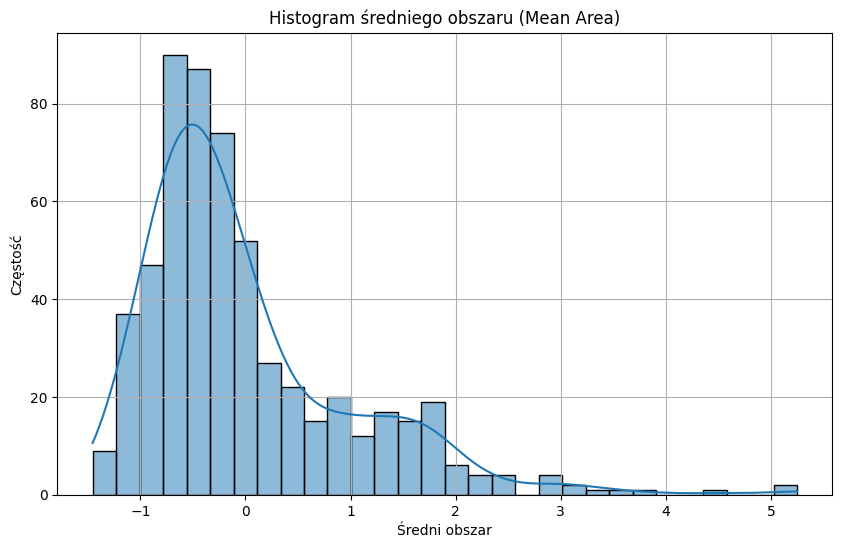

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# indeks kolumny mean area
feature_names = data.feature_names
mean_area_idx = list(feature_names).index('mean area')

# dane dla mean area
mean_area_data = x[:, mean_area_idx]

# histogram
plt.figure(figsize=(10, 6))
sns.histplot(mean_area_data, bins=30, kde=True)
plt.title('Histogram średniego obszaru (Mean Area)')
plt.xlabel('Średni obszar')
plt.ylabel('Częstość')
plt.grid(True)
plt.show()

4. narysuj wykres rozrzutu (scatterplot) sredniego obszaru od klasyfikacji (uzyj sns.regplot)

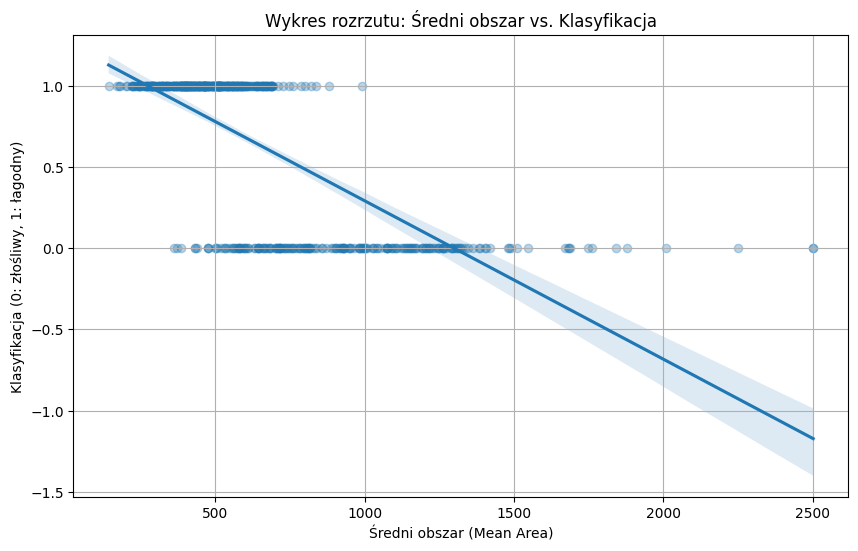

In [10]:
plt.figure(figsize=(10, 6))
sns.regplot(x=mean_area_data, y=y, scatter_kws={'alpha':0.3})
plt.title('Wykres rozrzutu: Średni obszar vs. Klasyfikacja')
plt.xlabel('Średni obszar (Mean Area)')
plt.ylabel('Klasyfikacja (0: złośliwy, 1: łagodny)')
plt.grid(True)
plt.show()

In [11]:
from sklearn.linear_model import LogisticRegression

In [22]:
from sklearn.preprocessing import StandardScaler
import numpy as np


current_mean = np.mean(x)
current_std = np.std(x)

print(f"Bieżąca średnia danych X: {current_mean:.2f}")
print(f"Bieżące odchylenie standardowe danych X: {current_std:.2f}")

if not (np.isclose(current_mean, 0.0, atol=1e-2) and np.isclose(current_std, 1.0, atol=1e-2)):
    print("Dane nie są ustandaryzowane. Rozpoczynam standaryzację...")
    scaler = StandardScaler()
    x = scaler.fit_transform(x)
    print("Dane zostały ustandaryzowane.")

    new_mean = np.mean(x)
    new_std = np.std(x)
    print(f"Średnia danych X po standaryzacji: {new_mean:.2f}")
    print(f"Odchylenie standardowe danych X po standaryzacji: {new_std:.2f}")
else:
    print("Dane są już ustandaryzowane.")

Bieżąca średnia danych X: -0.00
Bieżące odchylenie standardowe danych X: 1.00
Dane są już ustandaryzowane.


podziel zbior danych na testowy 30% i uczący 70%

In [15]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

print(f"Rozmiar zbioru treningowego X: {x_train.shape}")
print(f"Rozmiar zbioru testowego X: {x_test.shape}")

Rozmiar zbioru treningowego X: (398, 30)
Rozmiar zbioru testowego X: (171, 30)


zwizualizuj wyniki używając

1.   from sklearn.metrics import ConfusionMatrixDisplay, confusion matrix
2.  from sklearn.metrics import RocCurveDisplay, roc curve



<Figure size 800x600 with 0 Axes>

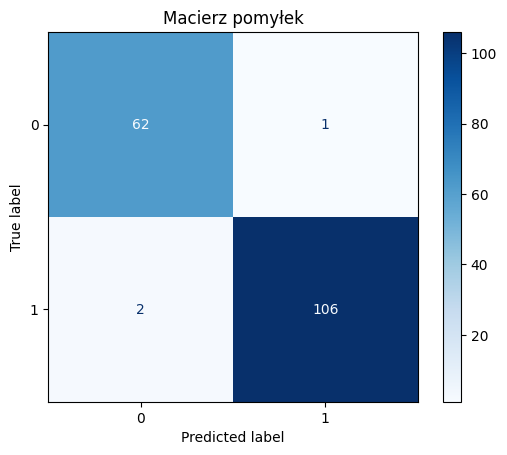

<Figure size 800x600 with 0 Axes>

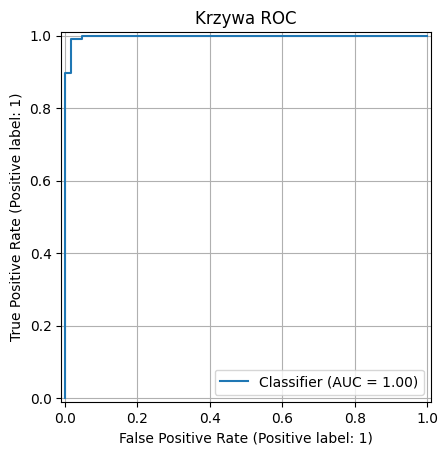

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, RocCurveDisplay, roc_curve
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
y_proba = model.predict_proba(x_test)[:, 1] # Prawdopodobieństwa dla klasy pozytywnej

# 1. Wizualizacja macierzy pomyłek
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap=plt.cm.Blues)
plt.title('Macierz pomyłek')
plt.grid(False)


# 2. Wizualizacja krzywej ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title('Krzywa ROC')
plt.grid(True)


porownaj klasyfikatory regresji logositycznej i knn metodą ROC i AUC

In [17]:
from sklearn.datasets import load_breast_cancer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import auc


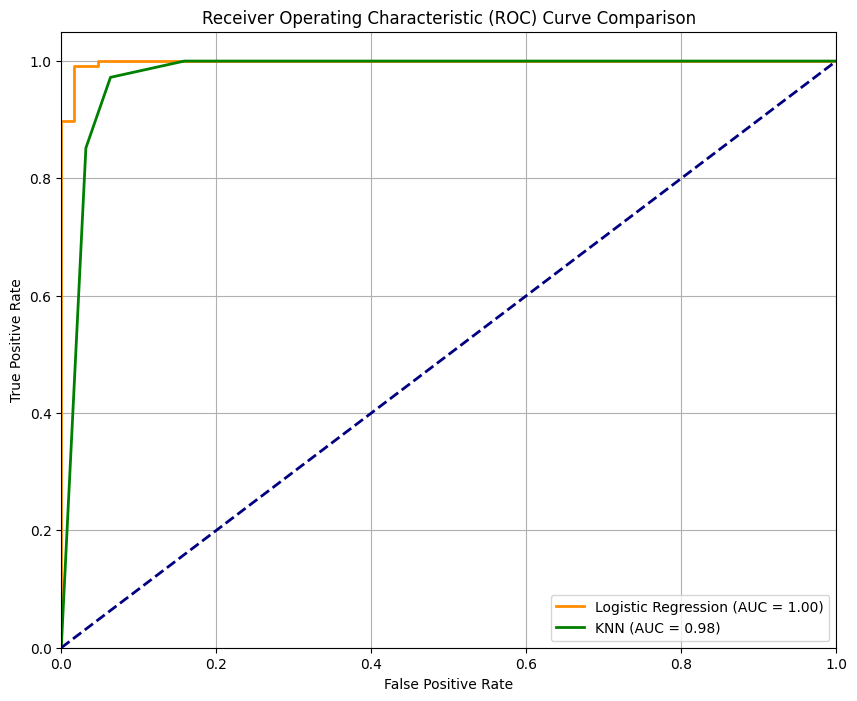

AUC for Logistic Regression: 1.00
AUC for KNN: 0.98


In [23]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


roc_auc_lr = auc(fpr, tpr)

knn_model = KNeighborsClassifier()
knn_model.fit(x_train, y_train)
y_proba_knn = knn_model.predict_proba(x_test)[:, 1]

fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn)
roc_auc_knn = auc(fpr_knn, tpr_knn)


plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')
plt.plot(fpr_knn, tpr_knn, color='green', lw=2, label=f'KNN (AUC = {roc_auc_knn:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"AUC for Logistic Regression: {roc_auc_lr:.2f}")
print(f"AUC for KNN: {roc_auc_knn:.2f}")

Zaimplementus drzewo decyzyjne i las losowy (złożony z 15 drzew), przetestuj na 30% zbiorze testowym

sklearn.ensemble.RandomForestClassifier

sklearn.tree.DecisionTreeClassifier


--- Decision Tree Classifier ---
Accuracy Score (Decision Tree): 0.9415
Classification Report (Decision Tree):
              precision    recall  f1-score   support

           0       0.90      0.95      0.92        63
           1       0.97      0.94      0.95       108

    accuracy                           0.94       171
   macro avg       0.93      0.94      0.94       171
weighted avg       0.94      0.94      0.94       171

AUC (Decision Tree): 0.9438

--- Random Forest Classifier (15 trees) ---
Accuracy Score (Random Forest): 0.9708
Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.97      0.95      0.96        63
           1       0.97      0.98      0.98       108

    accuracy                           0.97       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.97      0.97      0.97       171

AUC (Random Forest): 0.9966


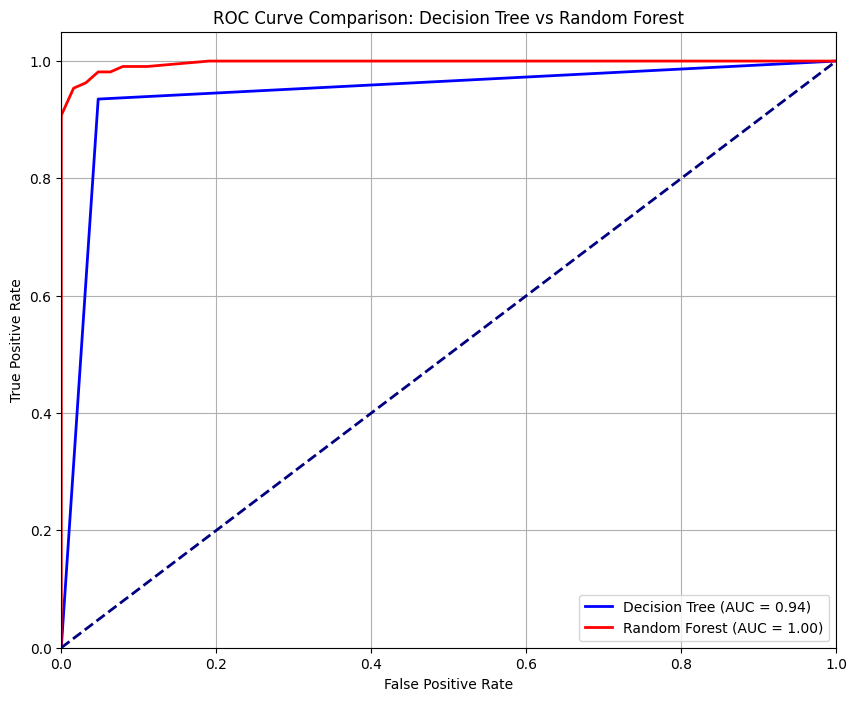

In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# 1. Decision Tree Classifier
print("\n--- Decision Tree Classifier ---")
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(x_train, y_train)

y_pred_dt = dtc.predict(x_test)
y_proba_dt = dtc.predict_proba(x_test)[:, 1]

print(f"Accuracy Score (Decision Tree): {accuracy_score(y_test, y_pred_dt):.4f}")
print("Classification Report (Decision Tree):")
print(classification_report(y_test, y_pred_dt))

# ROC and AUC for Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
roc_auc_dt = roc_auc_score(y_test, y_proba_dt)
print(f"AUC (Decision Tree): {roc_auc_dt:.4f}")

# 2. Random Forest Classifier
print("\n--- Random Forest Classifier (15 trees) ---")
rfc = RandomForestClassifier(n_estimators=15, random_state=42)
rfc.fit(x_train, y_train)

y_pred_rf = rfc.predict(x_test)
y_proba_rf = rfc.predict_proba(x_test)[:, 1]

print(f"Accuracy Score (Random Forest): {accuracy_score(y_test, y_pred_rf):.4f}")
print("Classification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))

# ROC and AUC for Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)
print(f"AUC (Random Forest): {roc_auc_rf:.4f}")

# Plotting
plt.figure(figsize=(10, 8))
plt.plot(fpr_dt, tpr_dt, color='blue', lw=2, label=f'Decision Tree (AUC = {roc_auc_dt:.2f})')
plt.plot(fpr_rf, tpr_rf, color='red', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: Decision Tree vs Random Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

zaimplementuj KNN oraz naiwny klasyfikator Bayesa


--- K-Nearest Neighbors Classifier ---
Accuracy Score (KNN): 0.9591
Classification Report (KNN):
              precision    recall  f1-score   support

           0       0.95      0.94      0.94        63
           1       0.96      0.97      0.97       108

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171

AUC (KNN): 0.9777

--- Naive Bayes Classifier ---
Accuracy Score (Naive Bayes): 0.9357
Classification Report (Naive Bayes):
              precision    recall  f1-score   support

           0       0.92      0.90      0.91        63
           1       0.94      0.95      0.95       108

    accuracy                           0.94       171
   macro avg       0.93      0.93      0.93       171
weighted avg       0.94      0.94      0.94       171

AUC (Naive Bayes): 0.9927


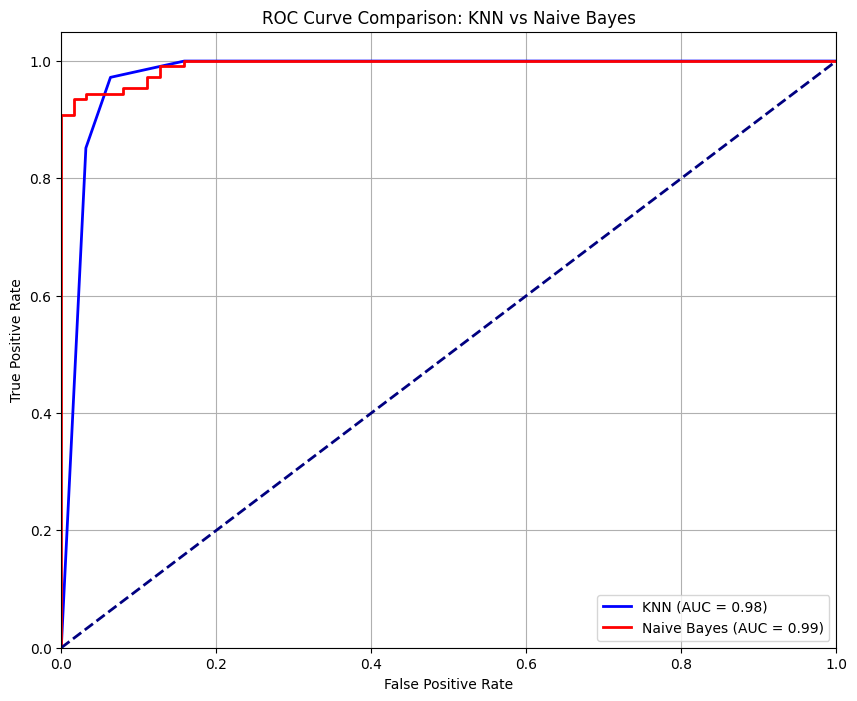

In [26]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# K-NN Classifier
print("\n--- K-Nearest Neighbors Classifier ---")
knn = KNeighborsClassifier()
knn.fit(x_train, y_train)

y_pred_knn = knn.predict(x_test)
y_proba_knn = knn.predict_proba(x_test)[:, 1]

print(f"Accuracy Score (KNN): {accuracy_score(y_test, y_pred_knn):.4f}")
print("Classification Report (KNN):")
print(classification_report(y_test, y_pred_knn))

fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn)
roc_auc_knn = roc_auc_score(y_test, y_proba_knn)
print(f"AUC (KNN): {roc_auc_knn:.4f}")

# Naive Bayes Classifier
print("\n--- Naive Bayes Classifier ---")
nb = GaussianNB()
nb.fit(x_train, y_train)

y_pred_nb = nb.predict(x_test)
y_proba_nb = nb.predict_proba(x_test)[:, 1]

print(f"Accuracy Score (Naive Bayes): {accuracy_score(y_test, y_pred_nb):.4f}")
print("Classification Report (Naive Bayes):")
print(classification_report(y_test, y_pred_nb))

fpr_nb, tpr_nb, _ = roc_curve(y_test, y_proba_nb)
roc_auc_nb = roc_auc_score(y_test, y_proba_nb)
print(f"AUC (Naive Bayes): {roc_auc_nb:.4f}")

# Plotting
plt.figure(figsize=(10, 8))
plt.plot(fpr_knn, tpr_knn, color='blue', lw=2, label=f'KNN (AUC = {roc_auc_knn:.2f})')
plt.plot(fpr_nb, tpr_nb, color='red', lw=2, label=f'Naive Bayes (AUC = {roc_auc_nb:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: KNN vs Naive Bayes')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## Podsumowanie i porównanie klasyfikatorów

Po zaimplementowaniu i ocenie różnych klasyfikatorów dla problemu klasyfikacji raka piersi, możemy podsumować ich wydajność na podstawie metryki AUC


  Las Losowy: AUC = 0.9966

  Naiwny Klasyfikator Bayesa : AUC = 0.9927

  K-NN: AUC = 0.9777

  Drzewo Decyzyjne: AUC = 0.9438

Wnioski:

Las Losowy wykazał się bardzo wysoką wydajnością, co czyni go solidnym wyborem ze względu na jego zdolność do radzenia sobie ze złożonymi zależnościami i redukcji przetrenowania w porównaniu do pojedynczego drzewa decyzyjnego.

Naiwny Klasyfikator Bayesa uzyskał również bardzo dobry wynik, co jest często spotykane w przypadku dobrze rozdzielonych danych.

Drzewo Decyzyjne i KNN miały nieco niższą wydajność, ale nadal oferują wartościowe spostrzeżenia i mogą być przydatne w innych kontekstach lub po dalszej optymalizacji hiperparametrów.